In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

DATA_DIR = Path("../../data/raw")
print("Data dir exists:", DATA_DIR.exists())
print("Files:", [f.name for f in DATA_DIR.iterdir()])

Data dir exists: True
Files: ['test_transaction.csv', 'train_identity.csv', 'test_identity.csv', 'train_transaction.csv']


In [4]:
%%time
txn_train = pd.read_csv(DATA_DIR / "train_transaction.csv")
id_train  = pd.read_csv(DATA_DIR / "train_identity.csv")

print(f"Transactions: {txn_train.shape}")
print(f"Identity:     {id_train.shape}")
print(f"\nFraud rate:   {txn_train['isFraud'].mean():.4f}")
print(f"Fraud count:  {txn_train['isFraud'].sum():,}")
print(f"Non-fraud:    {(txn_train['isFraud']==0).sum():,}")

Transactions: (590540, 394)
Identity:     (144233, 41)

Fraud rate:   0.0350
Fraud count:  20,663
Non-fraud:    569,877
CPU times: user 3.52 s, sys: 680 ms, total: 4.2 s
Wall time: 4.36 s


In [5]:
print("=== TRANSACTION TABLE ===")
print(f"Rows: {len(txn_train):,}")
print(f"Cols: {len(txn_train.columns)}")
print(f"Memory: {txn_train.memory_usage(deep=True).sum() / 1e9:.2f} GB")
print()
print("First 10 columns and their dtypes:")
print(txn_train.dtypes.head(10))
print()
print("Last 10 columns:")
print(txn_train.dtypes.tail(10))
print()
print("=== IDENTITY TABLE ===")
print(f"Rows: {len(id_train):,}")
print(f"Cols: {len(id_train.columns)}")
print()
print("All identity columns:")
print(id_train.columns.tolist())

=== TRANSACTION TABLE ===
Rows: 590,540
Cols: 394
Memory: 1.88 GB

First 10 columns and their dtypes:
TransactionID       int64
isFraud             int64
TransactionDT       int64
TransactionAmt    float64
ProductCD             str
card1               int64
card2             float64
card3             float64
card4                 str
card5             float64
dtype: object

Last 10 columns:
V330    float64
V331    float64
V332    float64
V333    float64
V334    float64
V335    float64
V336    float64
V337    float64
V338    float64
V339    float64
dtype: object

=== IDENTITY TABLE ===
Rows: 144,233
Cols: 41

All identity columns:
['TransactionID', 'id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06', 'id_07', 'id_08', 'id_09', 'id_10', 'id_11', 'id_12', 'id_13', 'id_14', 'id_15', 'id_16', 'id_17', 'id_18', 'id_19', 'id_20', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'D

In [6]:
# Identity table is sparse — not every transaction has it
overlap = txn_train["TransactionID"].isin(id_train["TransactionID"])
print(f"Transactions with identity data: {overlap.sum():,} ({overlap.mean():.1%})")
print(f"Transactions without identity:   {(~overlap).sum():,} ({(~overlap).mean():.1%})")

# Does identity coverage differ between fraud and non-fraud?
print("\nIdentity coverage by class:")
print(txn_train.assign(has_identity=overlap).groupby("isFraud")["has_identity"].mean())

Transactions with identity data: 144,233 (24.4%)
Transactions without identity:   446,307 (75.6%)

Identity coverage by class:
isFraud
0   0.2332
1   0.5477
Name: has_identity, dtype: float64


In [7]:
# Left join: every transaction stays, identity columns become NaN where missing
df = txn_train.merge(id_train, on="TransactionID", how="left")
print(f"Merged shape: {df.shape}")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

# Free memory — we don't need the originals anymore
del txn_train, id_train
import gc; gc.collect()

Merged shape: (590540, 434)
Memory: 2.08 GB


0

In [8]:
missing = df.isna().mean().sort_values(ascending=False)
print(f"Columns with >90% missing: {(missing > 0.90).sum()}")
print(f"Columns with >50% missing: {(missing > 0.50).sum()}")
print(f"Columns with  0% missing:  {(missing == 0).sum()}")

print("\nTop 15 most-missing columns:")
print(missing.head(15).to_string())

print("\nBottom 15 (most populated):")
print(missing.tail(15).to_string())

Columns with >90% missing: 12
Columns with >50% missing: 214
Columns with  0% missing:  20

Top 15 most-missing columns:
id_24   0.9920
id_25   0.9913
id_07   0.9913
id_08   0.9913
id_21   0.9913
id_26   0.9913
id_27   0.9912
id_23   0.9912
id_22   0.9912
dist2   0.9363
D7      0.9341
id_18   0.9236
D13     0.8951
D14     0.8947
D12     0.8904

Bottom 15 (most populated):
C10              0.0000
TransactionDT    0.0000
TransactionAmt   0.0000
ProductCD        0.0000
C6               0.0000
card1            0.0000
C8               0.0000
C7               0.0000
C5               0.0000
C4               0.0000
C3               0.0000
C2               0.0000
C1               0.0000
isFraud          0.0000
TransactionID    0.0000


TransactionDT range: 86400 to 15811131
Span in days: 182.0


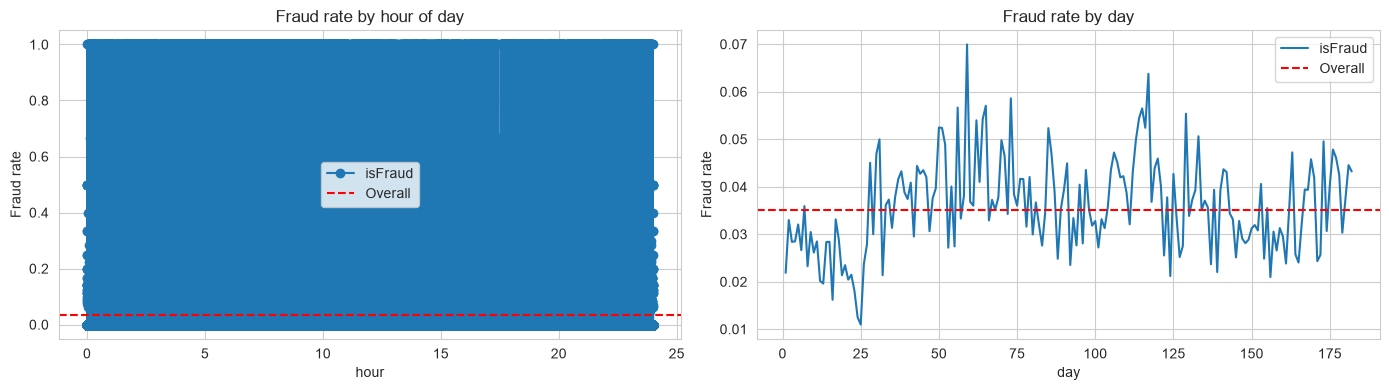

In [ ]:
# TransactionDT is seconds from a reference point (not a real timestamp)
# But we can still extract hour-of-day and day patterns
print("TransactionDT range:", df["TransactionDT"].min(), "to", df["TransactionDT"].max())
print(f"Span in days: {(df['TransactionDT'].max() - df['TransactionDT'].min()) / 86400:.1f}")

# Hour of day (assuming TransactionDT is in seconds)
df["hour"] = (df["TransactionDT"] / 3600) % 24
df["day"]  = (df["TransactionDT"] / 86400).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df.groupby("hour")["isFraud"].mean().plot(ax=axes[0], marker="o") #show fraud rate by hour of day
axes[0].set_title("Fraud rate by hour of day")
axes[0].set_ylabel("Fraud rate")
axes[0].axhline(df["isFraud"].mean(), color="red", linestyle="--", label="Overall")
axes[0].legend()

df.groupby("day")["isFraud"].mean().plot(ax=axes[1]) #show fraud rate by day
axes[1].set_title("Fraud rate by day")
axes[1].set_ylabel("Fraud rate")
axes[1].axhline(df["isFraud"].mean(), color="red", linestyle="--", label="Overall")
axes[1].legend()
plt.tight_layout()
plt.show()

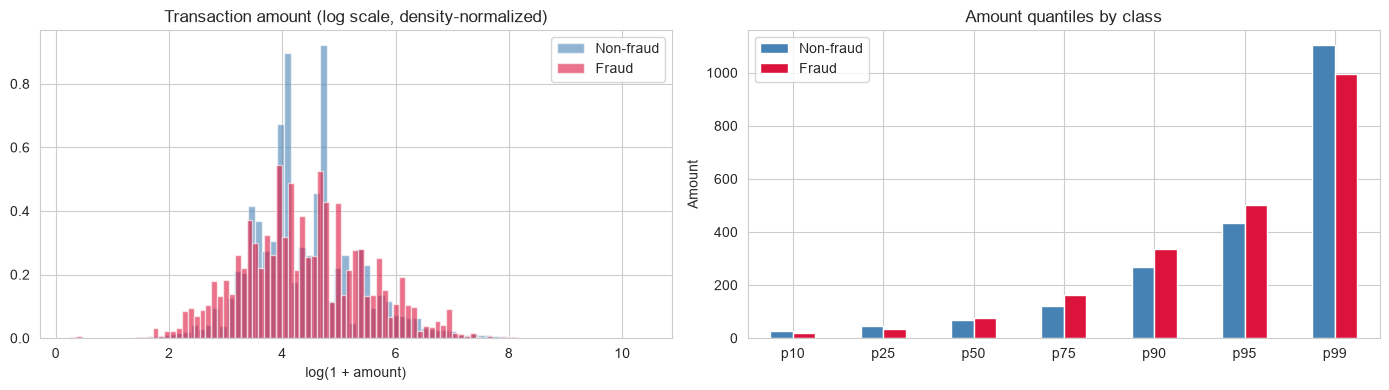


Amount stats:
            mean  median      std         max
isFraud                                      
0       134.5117 68.5000 239.3951 31,937.3910
1       149.2448 75.0000 232.2122  5,191.0000


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Log scale because amount is very skewed
df[df["isFraud"]==0]["TransactionAmt"].apply(np.log1p).hist(
    bins=80, alpha=0.6, label="Non-fraud", ax=axes[0], color="steelblue", density=True
)
df[df["isFraud"]==1]["TransactionAmt"].apply(np.log1p).hist(
    bins=80, alpha=0.6, label="Fraud", ax=axes[0], color="crimson", density=True
)
axes[0].set_title("Transaction amount (log scale, density-normalized)")
axes[0].set_xlabel("log(1 + amount)")
axes[0].legend()

# Quantile comparison
quantiles = [0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
q_table = pd.DataFrame({
    "Non-fraud": df[df["isFraud"]==0]["TransactionAmt"].quantile(quantiles),
    "Fraud":     df[df["isFraud"]==1]["TransactionAmt"].quantile(quantiles),
})
q_table.plot(kind="bar", ax=axes[1], color=["steelblue", "crimson"])
axes[1].set_title("Amount quantiles by class")
axes[1].set_ylabel("Amount")
axes[1].set_xticklabels([f"p{int(q*100)}" for q in quantiles], rotation=0)
plt.tight_layout()
plt.show()

print("\nAmount stats:")
print(df.groupby("isFraud")["TransactionAmt"].agg(["mean", "median", "std", "max"]))

ProductCD fraud rates and counts:
            mean   count
ProductCD               
C         0.1169   68519
S         0.0590   11628
H         0.0477   33024
R         0.0378   37699
W         0.0204  439670

card4 fraud rates and counts:
                   mean   count
card4                          
discover         0.0773    6651
visa             0.0348  384767
mastercard       0.0343  189217
american express 0.0287    8328


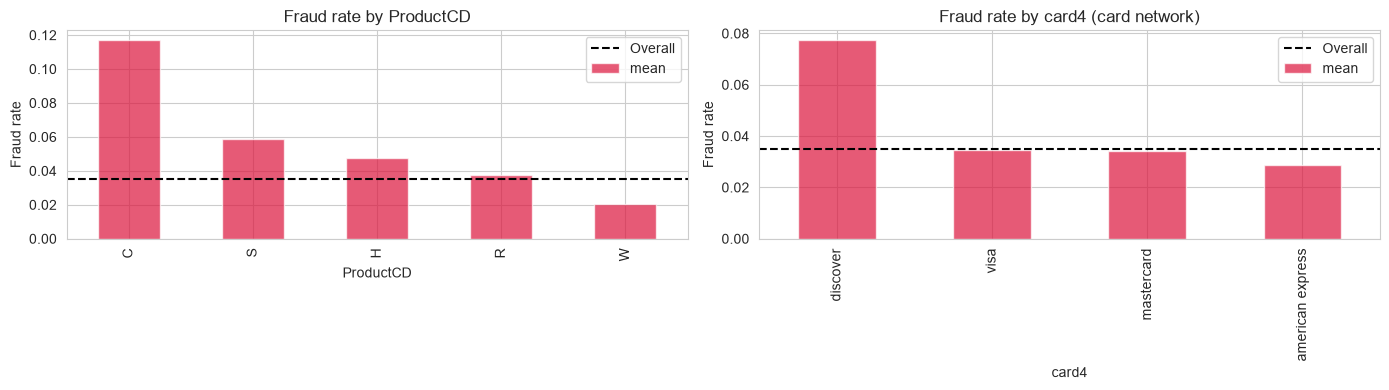

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ProductCD breakdown
pcd = df.groupby("ProductCD")["isFraud"].agg(["mean", "count"]).sort_values("mean", ascending=False)
pcd["mean"].plot(kind="bar", ax=axes[0], color="crimson", alpha=0.7)
axes[0].set_title("Fraud rate by ProductCD")
axes[0].set_ylabel("Fraud rate")
axes[0].axhline(df["isFraud"].mean(), color="black", linestyle="--", label="Overall")
axes[0].legend()
print("ProductCD fraud rates and counts:")
print(pcd)

# card4 (card network)
card4 = df.groupby("card4")["isFraud"].agg(["mean", "count"]).sort_values("mean", ascending=False)
card4["mean"].plot(kind="bar", ax=axes[1], color="crimson", alpha=0.7)
axes[1].set_title("Fraud rate by card4 (card network)")
axes[1].set_ylabel("Fraud rate")
axes[1].axhline(df["isFraud"].mean(), color="black", linestyle="--", label="Overall")
axes[1].legend()
print("\ncard4 fraud rates and counts:")
print(card4)

plt.tight_layout()
plt.show()